In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
mnist.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
print(f"NaNs in X_train: {np.isnan(X_train).sum()}")
print(f"NaNs in X_test: {np.isnan(X_test).sum()}")

NaNs in X_train: 0
NaNs in X_test: 0


In [ ]:
print(f"X_train has {X_train.shape[0]} rows and {X_train.shape[1]} columns.")
print(f"X_test has {X_test.shape[0]} rows and {X_test.shape[1]} columns.")

X_train has 60000 rows and 784 columns.
X_test has 10000 rows and 784 columns.


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_test.shape)


(60000, 28, 28)
(10000, 28, 28)


In [ ]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

X_train = X_train / 255.0
X_test = X_test / 255.0


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)










rf.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9704


In [ ]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
def add_noise(images, noise_factor):
    noisy = images + noise_factor * np.random.randn(*images.shape)
    noisy = np.clip(noisy, 0., 1.)
    return noisy


In [ ]:
noise_levels = [0.05, 0.10, 0.20, 0.30]

accuracies = []

for noise in noise_levels:

    noisy_test = add_noise(X_test, noise)

    predictions = rf.predict(noisy_test)

    acc = accuracy_score(y_test, predictions)

    accuracies.append(acc)

    print(f"Noise={noise:.2f} Accuracy={acc:.4f}")


Noise=0.05 Accuracy=0.7845
Noise=0.10 Accuracy=0.6978
Noise=0.20 Accuracy=0.6242
Noise=0.30 Accuracy=0.5741


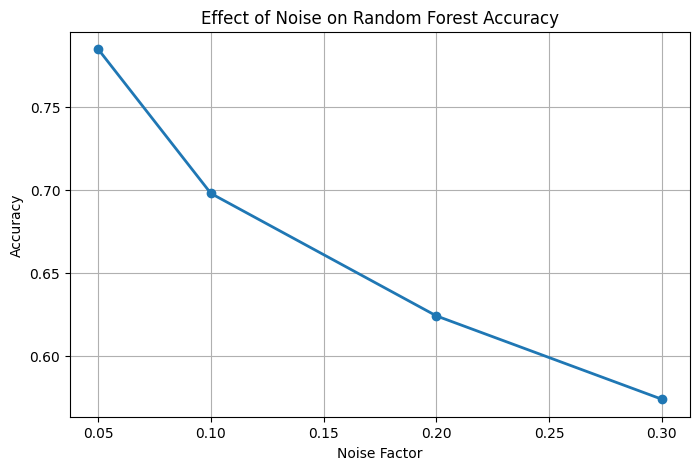

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(noise_levels,
         accuracies,
         marker='o',
         linewidth=2)

plt.xlabel("Noise Factor")
plt.ylabel("Accuracy")
plt.title("Effect of Noise on Random Forest Accuracy")

plt.grid(True)
plt.show()


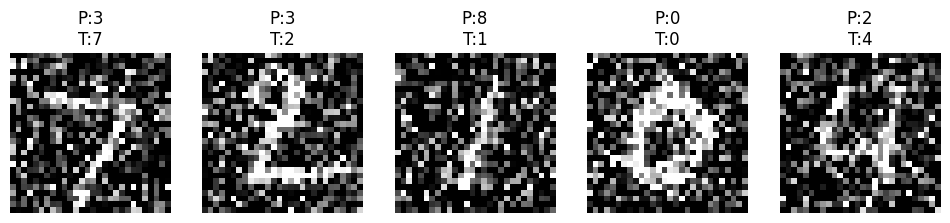

In [ ]:
noise = 0.5

noisy_images = add_noise(X_test, noise)

predictions = rf.predict(noisy_images)

plt.figure(figsize=(12,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(noisy_images[i].reshape(28,28), cmap='gray')

    plt.title(f"P:{predictions[i]}\nT:{y_test[i]}")

    plt.axis("off")

plt.show()


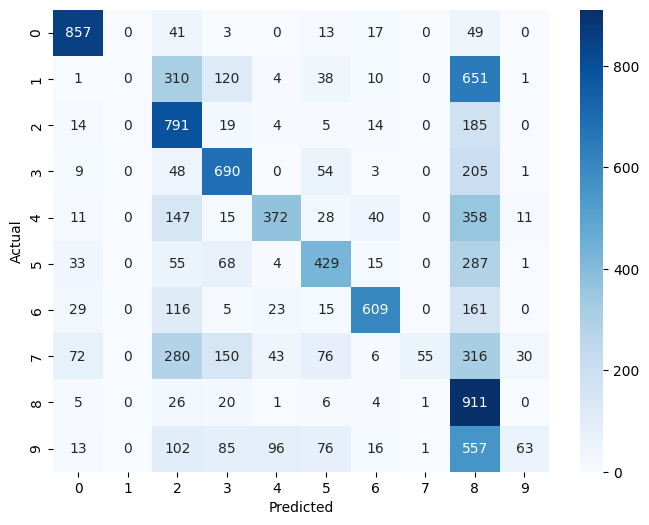

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
